In [2]:
# python 環境を整理する

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter

import tqdm
import glob
import re
import pickle
import os
from typing import List
import seaborn as sns
#sns.set() #推奨されないみたい
sns.set_style("white"+"grid")
#sns.set_palette("Paired")
import time
import plotly.express as px

#plt.rcParams['font.family'] = 'Times New Roman' # Fonts
plt.rcParams['mathtext.fontset'] = 'stix' # math fontの設定
plt.rcParams["font.size"] = 24 # 全体のフォントサイズが変更されます。
plt.rcParams['xtick.labelsize'] = 20 # 軸だけ変更されます。
plt.rcParams['ytick.labelsize'] = 20 # 軸だけ変更されます
color_arr=plt.rcParams['axes.prop_cycle'].by_key()['color']

#pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
df=pd.read_csv("r.txt",names=["from","to","timestamp","cnt","fx","fy","tx","ty"])
df=df.iloc[:10000]
df

,from,to,timestamp,cnt,fx,fy,tx,ty
0,20537,5352,50143.0,1,2061.020303,3000.000000,2043.000000,3000.000000
1,5352,20537,50143.0,2,2043.000000,3000.000000,2061.020303,3000.000000
2,5352,876,50191.0,1,1994.700856,3000.000000,2013.020303,3000.000000
3,876,5352,50192.0,3,2012.020303,3000.000000,1995.700856,3000.000000
4,20537,19050,50210.0,1,2129.387734,3000.000000,2110.000000,3000.000000
...,...,...,...,...,...,...,...,...
9995,15421,20623,54272.0,15,3643.924488,2250.000000,3625.005821,2250.000000
9996,14521,20643,54272.0,15,3750.000000,2685.676948,3750.000000,2704.724554
9997,20623,15421,54272.0,87,3625.005821,2250.000000,3643.924488,2250.000000
9998,20599,15123,54273.0,31,2625.000000,2799.260434,2625.000000,2780.158631


In [6]:
fig = px.scatter_3d(df,x="fx",y="fy",z="timestamp",color="cnt")

# 散布図の点の大きさを小さくする（例：size=2）
fig.update_traces(marker=dict(size=1))

# 凡例を非表示にする（line_idごとの凡例は不要な場合）
fig.update_layout(showlegend=False)
# グラフを表示
fig.show()

In [9]:
fig = px.line_3d(df, 
                 x='fx', 
                 y='fy', 
                 z='timestamp',
                 color='from',  # line_idごとに色を変えて線を区別
                 line_group="from", 
                 #opacity=0.5,      # 透明度を0.5に設定
                 #title='3D Lines from CSV Data'
                 )
# 凡例を非表示にする（line_idごとの凡例は不要な場合）
fig.update_layout(showlegend=False)
# グラフを表示
fig.show()

In [8]:
df

,from,to,timestamp,cnt,fx,fy,tx,ty
0,20537,5352,50143.0,1,2061.020303,3000.000000,2043.000000,3000.000000
1,5352,20537,50143.0,2,2043.000000,3000.000000,2061.020303,3000.000000
2,5352,876,50191.0,1,1994.700856,3000.000000,2013.020303,3000.000000
3,876,5352,50192.0,3,2012.020303,3000.000000,1995.700856,3000.000000
4,20537,19050,50210.0,1,2129.387734,3000.000000,2110.000000,3000.000000
...,...,...,...,...,...,...,...,...
9995,15421,20623,54272.0,15,3643.924488,2250.000000,3625.005821,2250.000000
9996,14521,20643,54272.0,15,3750.000000,2685.676948,3750.000000,2704.724554
9997,20623,15421,54272.0,87,3625.005821,2250.000000,3643.924488,2250.000000
9998,20599,15123,54273.0,31,2625.000000,2799.260434,2625.000000,2780.158631


In [6]:
from_id=df["from"].unique()
to_id=df["to"].unique()
position_dict={}

lines=[]

for id in from_id:
    part = df[df["from"]==id]
    for i in range(len(part)):
        c = part.iloc[i]
        lines.append([id,c["to"],c["fx"],c["fy"],c["timestamp"]])
    
plot_df=pd.DataFrame(lines,columns=["from","to","x","y","z"])
plot_df

,from,to,x,y,z
0,5907,2546.0,1984.932527,3000.000000,50065.0
1,5907,1950.0,2017.808909,3000.000000,50099.0
2,5907,3125.0,2057.713470,3000.000000,50139.0
3,5907,5229.0,2098.925197,3000.000000,50180.0
4,5907,3713.0,2204.162681,3000.000000,50285.0
...,...,...,...,...,...
3102,11193,11379.0,1480.926123,3000.000000,99901.0
3103,11193,11766.0,1468.373491,3000.000000,99915.0
3104,11193,11607.0,1401.006842,3000.000000,99983.0
3105,11580,11763.0,1500.000000,4519.357692,99915.0


In [ ]:
# --- Plotlyで3Dグラフを作成 ---
# px.line_3d()を使って、'line_id'ごとに線を引く
fig = px.line_3d(plot_df, 
                 x='x', 
                 y='y', 
                 z='z',
                 color='from',  # line_idごとに色を変えて線を区別
                 line_group="from", 
                 #opacity=0.5,      # 透明度を0.5に設定
                 #title='3D Lines from CSV Data'
                 )

# 凡例を非表示にする（line_idごとの凡例は不要な場合）
fig.update_layout(showlegend=False)

# グラフを表示
fig.show()

In [90]:
from_id=df["from"].unique()
to_id=df["to"].unique()
position_dict={}

line_id=0
lines=[]
for id in from_id:
    part_df=df[df["from"]==id]
    zmin,zmax=None,None
    for i in range(len(part_df)):
        c=part_df.iloc[i]
        if c["from"] not in position_dict.keys():
            position_dict[c["from"]]={"x":(np.random.rand()-0.5)*5,"y":(np.random.rand()-0.5)*5,"zmin":None,"zmax":None}
        if c["to"] not in position_dict.keys():
            position_dict[c["to"]]={"x":position_dict[c["from"]]["x"]+(np.random.rand()-0.5)*10,"y":position_dict[c["from"]]["y"]+(np.random.rand()-0.5)*10,"zmin":None,"zmax":None}
            
        lines.append([c["from"],c["to"],position_dict[c["from"]]["x"],position_dict[c["from"]]["y"],c["timestamp"],line_id])
        lines.append([c["from"],c["to"],position_dict[c["to"]]["x"],position_dict[c["to"]]["y"],c["timestamp"],line_id])
        if position_dict[c["from"]]["zmin"] is None or position_dict[c["from"]]["zmin"]<c["timestamp"]:
            position_dict[c["from"]]["zmin"]=c["timestamp"]
        if position_dict[c["from"]]["zmax"] is None or position_dict[c["from"]]["zmax"]>c["timestamp"]:
            position_dict[c["from"]]["zmax"]=c["timestamp"]
        if position_dict[c["to"]]["zmin"] is None or position_dict[c["to"]]["zmin"]<c["timestamp"]:
            position_dict[c["to"]]["zmin"]=c["timestamp"]
        if position_dict[c["to"]]["zmax"] is None or position_dict[c["to"]]["zmax"]>c["timestamp"]:
            position_dict[c["to"]]["zmax"]=c["timestamp"]
        line_id+=1

for id in from_id:
    lines.append([id,id,position_dict[id]["x"],position_dict[id]["y"],position_dict[id]["zmin"],line_id])
    lines.append([id,id,position_dict[id]["x"],position_dict[id]["y"],position_dict[id]["zmax"],line_id])
    line_id+=1
    
plot_df=pd.DataFrame(lines,columns=["from","to","x","y","z","line_id"])
plot_df

,from,to,x,y,z,line_id
0,5907.0,2546.0,-2.464910,-0.472827,50065.0,0
1,5907.0,2546.0,1.198750,0.886444,50065.0,0
2,5907.0,1950.0,-2.464910,-0.472827,50099.0,1
3,5907.0,1950.0,2.002073,1.195327,50099.0,1
4,5907.0,3125.0,-2.464910,-0.472827,50139.0,2
...,...,...,...,...,...,...
2697,7556.0,7556.0,-8.492433,13.746773,65728.0,1348
2698,7568.0,7568.0,2.718023,3.227578,68893.0,1349
2699,7568.0,7568.0,2.718023,3.227578,67241.0,1349
2700,7195.0,7195.0,-23.441709,9.798958,68869.0,1350


In [91]:
import plotly.express as px

# --- Plotlyで3Dグラフを作成 ---
# px.line_3d()を使って、'line_id'ごとに線を引く
fig = px.line_3d(plot_df, 
                 x='x', 
                 y='y', 
                 z='z',
                 color='from',  # line_idごとに色を変えて線を区別
                 line_group="line_id", 
                 #opacity=0.5,      # 透明度を0.5に設定
                 #title='3D Lines from CSV Data'
                 )

# 凡例を非表示にする（line_idごとの凡例は不要な場合）
fig.update_layout(showlegend=False)

# グラフを表示
fig.show()

In [ ]:
df[df["to"]==1677]

,from,to,timestamp
21,1677,3424,50997.0


In [5]:
import pandas as pd
import plotly.express as px

# --- CSVファイルの読み込み ---
# 元のコードと同じように、c.csvを読み込む
# 列名も同様に指定
df = pd.read_csv('c.csv', header=None, names=["start_h", 'start_x', 'start_y', "end_h", 'end_x', 'end_y'])

# --- Plotlyが扱いやすいようにデータを整形 ---
# Plotlyのpx.line_3dは、1つの線を描く際に、その線の全データポイントが連続した行にあることを期待します。
# そのため、始点と終点のデータをまとめて、どの線に属するかを示す'line_id'列を追加します。
start_points = df[['start_x', 'start_y', 'start_h']].rename(columns={
    'start_x': 'x',
    'start_y': 'y',
    'start_h': 'z'
})
end_points = df[['end_x', 'end_y', 'end_h']].rename(columns={
    'end_x': 'x',
    'end_y': 'y',
    'end_h': 'z'
})

# 始点と終点のデータに、それぞれの線IDを割り当てる
start_points['line_id'] = range(len(start_points))
end_points['line_id'] = range(len(end_points))

# 始点と終点のデータを結合
# この新しいデータフレームで、各line_idのデータが2行ずつになります
plot_df = pd.concat([start_points, end_points]).sort_values(by='line_id').reset_index(drop=True)

# --- Plotlyで3Dグラフを作成 ---
# px.line_3d()を使って、'line_id'ごとに線を引く
# opacityパラメータで透明度を設定します
fig = px.line_3d(plot_df, 
                 x='x', 
                 y='y', 
                 z='z',
                 color='line_id',  # line_idごとに色を変えて線を区別
                 #opacity=0.5,      # 透明度を0.5に設定
                 title='3D Lines from CSV Data')

# 凡例を非表示にする（line_idごとの凡例は不要な場合）
fig.update_layout(showlegend=False)

# グラフを表示
fig.show()

In [6]:
plot_df

,x,y,z,line_id
0,0.000000,0.000000,0.000000,0
1,120.000000,0.000000,16.803754,0
2,180.000000,0.000000,32.465739,1
3,120.000000,0.000000,16.803754,1
4,180.000000,0.000000,32.465739,2
...,...,...,...,...
385,150.209401,-98.417621,174.492037,192
386,180.209401,-98.417621,191.730379,193
387,150.209401,-98.417621,174.492037,193
388,120.209401,-98.417621,195.801344,194


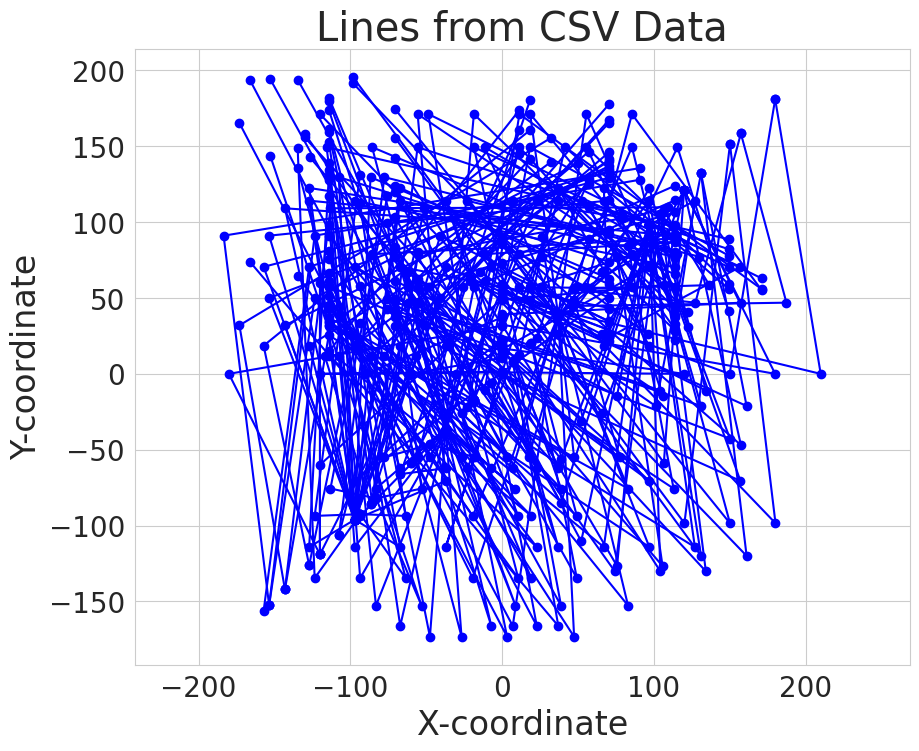

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# CSVファイルからデータを読み込む
# ファイル名や列名はご自身のデータに合わせて変更してください
df = pd.read_csv('c.csv', header=None, names=["height",'start_x', 'start_y', 'end_x', 'end_y'])

# 図のサイズを設定
plt.figure(figsize=(10, 8))

# 各行の始点と終点を結んで線を描画
for index, row in df.iterrows():
    # 始点と終点の座標を抽出
    x_coords = [row['start_x'], row['end_x'], row["height"]]
    y_coords = [row['start_y'], row['end_y'], row['height']+1]
    
    # 線を描画
    plt.plot(x_coords, y_coords, marker='o', linestyle='-', color='b')

# グラフの設定
plt.title('Lines from CSV Data')
plt.xlabel('X-coordinate')
plt.ylabel('Y-coordinate')
plt.grid(True)
plt.axis('equal') # X軸とY軸のスケールを合わせる
plt.show()

/tmp/ipykernel_18075/331606124.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


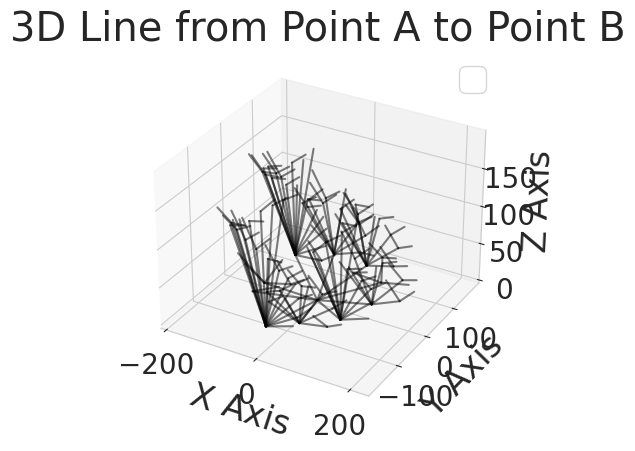

In [7]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 始点と終点の座標
point_a = [1, 2, 3]
point_b = [5, 6, 7]
df = pd.read_csv('c.csv', header=None, names=["start_h",'start_x', 'start_y', "end_h", 'end_x', 'end_y'])


# 始点と終点のx, y, z座標を別々のリストにまとめる
x_coords = [point_a[0], point_b[0]]
y_coords = [point_a[1], point_b[1]]
z_coords = [point_a[2], point_b[2]]


# 3Dプロット用の描画領域を準備
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 線を描画
# ax.plot(xのリスト, yのリスト, zのリスト)
#ax.plot(x_coords, y_coords, z_coords)

for index, row in df.iterrows():
    # 始点と終点の座標を抽出
    x_coords = [row['start_x'], row['end_x']]
    y_coords = [row['start_y'], row['end_y']]
    z_coords = [row["start_h"], row["end_h"]]
    # 線を描画
    ax.plot(x_coords, y_coords, z_coords, color="k", alpha=0.5)
    
    #plt.plot(x_coords, y_coords, marker='o', linestyle='-', color='b')

# 始点と終点にマーカーを付ける
#ax.scatter(point_a[0], point_a[1], point_a[2], c='red', marker='o', label='Start Point')
#ax.scatter(point_b[0], point_b[1], point_b[2], c='blue', marker='o', label='End Point')

# グラフのタイトルと軸ラベルを設定
ax.set_title('3D Line from Point A to Point B')
ax.set_xlabel('X Axis')
ax.set_ylabel('Y Axis')
ax.set_zlabel('Z Axis')
ax.legend()

# グラフを表示
plt.show()

In [9]:
import pandas as pd
import plotly.express as px

# --- CSVファイルの読み込み ---
# 元のコードと同じように、c.csvを読み込む
# 列名も同様に指定
df = pd.read_csv('c.csv', header=None, names=["start_h", 'start_x', 'start_y', "end_h", 'end_x', 'end_y'])

# --- Plotlyが扱いやすいようにデータを整形 ---
# Plotlyのpx.line_3dは、1つの線を描く際に、その線の全データポイントが連続した行にあることを期待します。
# そのため、始点と終点のデータをまとめて、どの線に属するかを示す'line_id'列を追加します。
start_points = df[['start_x', 'start_y', 'start_h']].rename(columns={
    'start_x': 'x',
    'start_y': 'y',
    'start_h': 'z'
})
end_points = df[['end_x', 'end_y', 'end_h']].rename(columns={
    'end_x': 'x',
    'end_y': 'y',
    'end_h': 'z'
})

# 始点と終点のデータに、それぞれの線IDを割り当てる
start_points['line_id'] = range(len(start_points))
end_points['line_id'] = range(len(end_points))

# 始点と終点のデータを結合
# この新しいデータフレームで、各line_idのデータが2行ずつになります
plot_df = pd.concat([start_points, end_points]).sort_values(by='line_id').reset_index(drop=True)

# --- Plotlyで3Dグラフを作成 ---
# px.line_3d()を使って、'line_id'ごとに線を引く
# opacityパラメータで透明度を設定します
fig = px.line_3d(plot_df, 
                 x='x', 
                 y='y', 
                 z='z',
                 color='line_id',  # line_idごとに色を変えて線を区別
                 #opacity=0.5,      # 透明度を0.5に設定
                 title='3D Lines from CSV Data')

# 凡例を非表示にする（line_idごとの凡例は不要な場合）
fig.update_layout(showlegend=False)

# グラフを表示
fig.show()